# SAM-Med2D Fine-tuned — Test Only (Robust Bbox)

Thứ tự chạy: **Setup → Chuẩn bị → (%%writefile) → Test A / B / C → Kết quả**

In [1]:
%cd /kaggle/working

# ── Cài đặt gói ──────────────────────────────────────────────────
!pip install -q albumentations gdown

import os, gdown, cv2, json as _json, numpy as np, glob

# ── Clone SAM-Med2D ───────────────────────────────────────────────
if not os.path.exists('SAM-Med2D'):
    !git clone -q https://github.com/OpenGVLab/SAM-Med2D/

%cd /kaggle/working/SAM-Med2D

# ── Dataset ───────────────────────────────────────────────────────
if not os.path.exists('dataset_FracAtlas'):
    gdown.download('https://drive.google.com/uc?id=1o4WUbs9faT6T-F-i59tPKSQNaROBY4DL',
                   '/tmp/dataset_FracAtlas.zip', quiet=False)
    !unzip -oq /tmp/dataset_FracAtlas.zip -d /kaggle/working/SAM-Med2D/

# ── Per-polygon masks: JSON annotation → PNG riêng từng polygon ──
def build_per_polygon_masks(split):
    ann_dir  = f"dataset_FracAtlas/{split}/annotations"
    mask_dir = f"dataset_FracAtlas/{split}/masks"
    img_dir  = f"dataset_FracAtlas/{split}/images"
    if not os.path.exists(ann_dir):
        print(f"[!] {split}: không có annotations, bỏ qua"); return
    for p in glob.glob(os.path.join(mask_dir, "*.png")): os.remove(p)
    n = 0
    for jf in sorted(glob.glob(os.path.join(ann_dir, "*.json"))):
        base = os.path.splitext(os.path.basename(jf))[0]
        img_path = next(
            (os.path.join(img_dir, base + e) for e in ('.png', '.jpg', '.jpeg')
             if os.path.exists(os.path.join(img_dir, base + e))), None)
        if img_path is None: continue
        img  = cv2.imread(img_path)
        H, W = img.shape[:2]
        data = _json.load(open(jf, encoding='utf-8'))
        polys = [s for s in data.get('shapes', []) if s.get('shape_type') == 'polygon']
        for i, shp in enumerate(polys, 1):
            pts  = np.array(shp['points'], dtype=np.float32).reshape(-1, 1, 2).astype(np.int32)
            mask = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(mask, [pts], 255)
            cv2.imwrite(os.path.join(mask_dir, f"{base}_{i}.png"), mask)
            n += 1
    print(f"[✅] {split}: {n} per-polygon masks")

for split in ['train', 'val', 'test']:
    build_per_polygon_masks(split)

# ── Fine-tuned checkpoint ─────────────────────────────────────────
CKPT_ID    = '1c-J0SEYKEO3RXq736ASdDDVWEHFXRoAf'
CKPT_LOCAL = '/kaggle/working/SAM-Med2D/checkpoint/best_sam.pth'
os.makedirs(os.path.dirname(CKPT_LOCAL), exist_ok=True)
if not os.path.exists(CKPT_LOCAL):
    gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_LOCAL, quiet=False)
assert os.path.exists(CKPT_LOCAL), '❌ Tải checkpoint thất bại'
print(f'\n✅ Setup xong | {CKPT_LOCAL}  ({os.path.getsize(CKPT_LOCAL)//1024//1024} MB)')

/kaggle/working
/kaggle/working/SAM-Med2D


Downloading...
From (original): https://drive.google.com/uc?id=1o4WUbs9faT6T-F-i59tPKSQNaROBY4DL
From (redirected): https://drive.google.com/uc?id=1o4WUbs9faT6T-F-i59tPKSQNaROBY4DL&confirm=t&uuid=28de0992-c313-4d77-b532-3ccdafe8473b
To: /tmp/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:04<00:00, 53.6MB/s] 


[✅] train: 730 per-polygon masks
[✅] val: 95 per-polygon masks
[✅] test: 92 per-polygon masks


Downloading...
From (original): https://drive.google.com/uc?id=1c-J0SEYKEO3RXq736ASdDDVWEHFXRoAf
From (redirected): https://drive.google.com/uc?id=1c-J0SEYKEO3RXq736ASdDDVWEHFXRoAf&confirm=t&uuid=4513839b-dede-463d-995a-891d51b7ace3
To: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
100%|██████████| 2.56G/2.56G [01:02<00:00, 40.9MB/s]


✅ Setup xong | /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth  (2443 MB)


## Phần 2 – Thí nghiệm Đánh giá

Ba kịch bản prompt bbox:
- **A – Zoom-Out ~30%**: bbox mở rộng đều 4 phía 30%
- **B – Shift ~30%**: bbox lệch vị trí ~30%
- **C – Mixed 70/30**: 70% zoom-out + 30% shift

### 2.0 – Chuẩn bị (chạy 1 lần trước khi test)

In [2]:
%cd /kaggle/working/SAM-Med2D
import os, json, glob, gdown

# ── Tạo label2image_test.json & label2image_val.json ─────────────
def create_evaluation_json(split="test"):
    mask_dir = f"dataset_FracAtlas/{split}/masks"
    img_dir  = f"dataset_FracAtlas/{split}/images"
    label2image = {}
    if not os.path.exists(mask_dir) or not os.path.exists(img_dir):
        print(f"[!] Không tìm thấy thư mục cho tập: '{split}'"); return
    img_dict = {}
    for f in os.listdir(img_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_dict[os.path.splitext(f)[0]] = f
    for mask_name in sorted(os.listdir(mask_dir)):
        if not mask_name.lower().endswith(('.png', '.jpg', '.jpeg')): continue
        mask_base = os.path.splitext(mask_name)[0]
        img_base  = mask_base.rsplit('_', 1)[0] if '_' in mask_base else mask_base
        if img_base in img_dict:
            label2image[f"dataset_FracAtlas/{split}/masks/{mask_name}"] = \
                        f"dataset_FracAtlas/{split}/images/{img_dict[img_base]}"
    out = f"dataset_FracAtlas/label2image_{split}.json"
    with open(out, "w", encoding="utf-8") as fo:
        json.dump(label2image, fo, indent=4, ensure_ascii=False)
    print(f"[*] label2image_{split}.json — {len(label2image)} mẫu → {out}")

create_evaluation_json("test")
create_evaluation_json("val")

# ── Load CHECKPOINT (Drive-mount → checkpoint/ → workdir → tải về) ───────────
CKPT_DRIVE_ID = '1c-J0SEYKEO3RXq736ASdDDVWEHFXRoAf'
CKPT_LOCAL    = '/kaggle/working/SAM-Med2D/checkpoint/best_sam.pth'

def find_ckpt(folder):
    for name in ["best_sam.pth", "last_sam.pth"]:
        p = os.path.join(folder, name)
        if os.path.exists(p): return p
    return None

CHECKPOINT = (find_ckpt("/kaggle/working/drive/MyDrive/model") or
              find_ckpt("/kaggle/working/SAM-Med2D/checkpoint") or
              find_ckpt("/kaggle/working/SAM-Med2D/workdir/models/sam-med2d"))

if CHECKPOINT:
    src = "Drive-mount" if "MyDrive" in CHECKPOINT else "Local"
    print(f"[{src}] ✅ {CHECKPOINT}")
else:
    print("[Download] Tải fine-tuned checkpoint từ Google Drive...")
    os.makedirs(os.path.dirname(CKPT_LOCAL), exist_ok=True)
    gdown.download(f'https://drive.google.com/uc?id={CKPT_DRIVE_ID}', CKPT_LOCAL, quiet=False)
    CHECKPOINT = CKPT_LOCAL

assert os.path.exists(CHECKPOINT), "❌ Checkpoint không tồn tại!"
print(f"\n✅ Checkpoint: {CHECKPOINT}  ({os.path.getsize(CHECKPOINT)//1024//1024} MB)")

/kaggle/working/SAM-Med2D
[*] label2image_test.json — 92 mẫu → dataset_FracAtlas/label2image_test.json
[*] label2image_val.json — 95 mẫu → dataset_FracAtlas/label2image_val.json
[Local] ✅ /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth

✅ Checkpoint: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth  (2443 MB)


In [3]:
%%writefile /kaggle/working/SAM-Med2D/segment_anything/build_sam.py
# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.

import torch
from functools import partial
from .modeling import ImageEncoderViT, MaskDecoder, PromptEncoder, Sam, TwoWayTransformer
from torch.nn import functional as F

def build_sam_vit_h(args):
    return _build_sam(
        encoder_embed_dim=1280,
        encoder_depth=32,
        encoder_num_heads=16,
        encoder_global_attn_indexes=[7, 15, 23, 31],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

build_sam = build_sam_vit_h

def build_sam_vit_l(args):
    return _build_sam(
        encoder_embed_dim=1024,
        encoder_depth=24,
        encoder_num_heads=16,
        encoder_global_attn_indexes=[5, 11, 17, 23],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

def build_sam_vit_b(args):
    return _build_sam(
        encoder_embed_dim=768,
        encoder_depth=12,
        encoder_num_heads=12,
        encoder_global_attn_indexes=[2, 5, 8, 11],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

sam_model_registry = {
    "default": build_sam_vit_h,
    "vit_h":   build_sam_vit_h,
    "vit_l":   build_sam_vit_l,
    "vit_b":   build_sam_vit_b,
}

def _build_sam(encoder_embed_dim, encoder_depth, encoder_num_heads,
               encoder_global_attn_indexes, image_size, checkpoint, encoder_adapter):
    prompt_embed_dim = 256
    vit_patch_size   = 16
    image_embedding_size = image_size // vit_patch_size
    sam = Sam(
        image_encoder=ImageEncoderViT(
            depth=encoder_depth,
            embed_dim=encoder_embed_dim,
            img_size=image_size,
            mlp_ratio=4,
            norm_layer=partial(torch.nn.LayerNorm, eps=1e-6),
            num_heads=encoder_num_heads,
            patch_size=vit_patch_size,
            qkv_bias=True,
            use_rel_pos=True,
            global_attn_indexes=encoder_global_attn_indexes,
            window_size=14,
            out_chans=prompt_embed_dim,
            adapter_train=encoder_adapter,
        ),
        prompt_encoder=PromptEncoder(
            embed_dim=prompt_embed_dim,
            image_embedding_size=(image_embedding_size, image_embedding_size),
            input_image_size=(image_size, image_size),
            mask_in_chans=16,
        ),
        mask_decoder=MaskDecoder(
            num_multimask_outputs=3,
            transformer=TwoWayTransformer(
                depth=2,
                embedding_dim=prompt_embed_dim,
                mlp_dim=2048,
                num_heads=8,
            ),
            transformer_dim=prompt_embed_dim,
            iou_head_depth=3,
            iou_head_hidden_dim=256,
        ),
        pixel_mean=[123.675, 116.28, 103.53],
        pixel_std=[58.395, 57.12, 57.375],
    )
    if checkpoint is not None:
        with open(checkpoint, "rb") as f:
            state_dict = torch.load(f, map_location="cpu", weights_only=False)
        try:
            if 'model' in state_dict:
                print(encoder_adapter)
                sam.load_state_dict(state_dict['model'], strict=False)
            else:
                if image_size == 1024 and encoder_adapter:
                    sam.load_state_dict(state_dict, strict=False)
                else:
                    sam.load_state_dict(state_dict)
        except Exception:
            print('**** interpolate pos embed')
            new_state_dict = load_from(sam, state_dict, image_size, vit_patch_size)
            sam.load_state_dict(new_state_dict)
        print(f"**** loaded {checkpoint}")
    return sam

def load_from(sam, state_dicts, image_size, vit_patch_size):
    sam_dict    = sam.state_dict()
    skip_keys   = ['mask_tokens', 'output_hypernetworks_mlps', 'iou_prediction_head']
    new_sd      = {k: v for k, v in state_dicts.items()
                   if k in sam_dict and not any(s in k for s in skip_keys)}
    pos_embed   = new_sd.get('image_encoder.pos_embed')
    token_size  = image_size // vit_patch_size
    if pos_embed is not None and pos_embed.shape[1] != token_size:
        pos_embed = F.interpolate(
            pos_embed.permute(0,3,1,2), (token_size, token_size),
            mode='bilinear', align_corners=False).permute(0,2,3,1)
        new_sd['image_encoder.pos_embed'] = pos_embed
        for k in [k for k in sam_dict if 'rel_pos' in k and
                  any(t in k for t in ['2','5','7','8','11','13','15','23','31'])]:
            rp = new_sd.get(k)
            if rp is not None:
                h_c, w_c = sam_dict[k].shape
                if rp.shape != (h_c, w_c):
                    rp = F.interpolate(rp.unsqueeze(0).unsqueeze(0),
                                       (h_c, w_c), mode='bilinear', align_corners=False)[0,0]
                new_sd[k] = rp
    sam_dict.update(new_sd)
    return sam_dict

Overwriting /kaggle/working/SAM-Med2D/segment_anything/build_sam.py


In [4]:
%%writefile /kaggle/working/SAM-Med2D/DataLoader.py
import os, json, random
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset
from torch.nn import functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from utils import train_transforms, get_boxes_from_mask, init_point_sampling


class TestingDataset(Dataset):
    def __init__(self, data_path, image_size=256, mode='test', requires_name=True,
                 point_num=1, return_ori_mask=True, prompt_path=None,
                 prompt_mode='zoom_out', zoom_ratio=(0.15, 0.45), shift_ratio=0.30):
        self.image_size    = image_size
        self.return_ori_mask = return_ori_mask
        self.prompt_path   = prompt_path
        self.prompt_list   = {} if prompt_path is None else json.load(open(prompt_path))
        self.requires_name = requires_name
        self.point_num     = point_num
        self.mode          = mode
        self.is_train      = (mode == 'train')
        self.prompt_mode   = prompt_mode
        self.zoom_ratio    = zoom_ratio
        self.shift_ratio   = shift_ratio

        dataset = json.load(open(os.path.join(data_path, f'label2image_{mode}.json')))
        sorted_items       = sorted(dataset.items(), key=lambda x: os.path.basename(x[0]))
        self.label_paths   = [k for k, v in sorted_items]
        self.image_paths   = [v for k, v in sorted_items]
        self.pixel_mean    = [123.675, 116.28, 103.53]
        self.pixel_std     = [58.395, 57.12, 57.375]

    def _zoom_out_bbox(self, x_min, x_max, y_min, y_max, orig_h, orig_w):
        gt_w, gt_h = x_max - x_min, y_max - y_min
        lo, hi = self.zoom_ratio
        if self.is_train:
            r_l, r_r = random.uniform(lo, hi), random.uniform(lo, hi)
            r_t, r_b = random.uniform(lo, hi), random.uniform(lo, hi)
        else:
            r = (lo + hi) / 2
            r_l = r_r = r_t = r_b = r
        return (max(0, x_min - gt_w*r_l), min(orig_w, x_max + gt_w*r_r),
                max(0, y_min - gt_h*r_t), min(orig_h, y_max + gt_h*r_b))

    def _shift_bbox(self, x_min, x_max, y_min, y_max, orig_h, orig_w, seed_idx=None):
        gt_w, gt_h = x_max - x_min, y_max - y_min
        bx_min, bx_max, by_min, by_max = self._zoom_out_bbox(
            x_min, x_max, y_min, y_max, orig_h, orig_w)
        if self.is_train:
            dx = random.uniform(-gt_w * self.shift_ratio, gt_w * self.shift_ratio)
            dy = random.uniform(-gt_h * self.shift_ratio, gt_h * self.shift_ratio)
        else:
            rng = random.Random(seed_idx or 0)
            dx  = rng.uniform(gt_w * 0.4, gt_w * 0.7) * self.shift_ratio
            dy  = rng.uniform(gt_h * 0.1, gt_h * 0.3) * self.shift_ratio
        bx_min = max(0,      bx_min + dx);  bx_max = min(orig_w, bx_max + dx)
        by_min = max(0,      by_min + dy);  by_max = min(orig_h, by_max + dy)
        if min(bx_max, x_max) - max(bx_min, x_min) < gt_w * 0.3:
            if dx > 0: bx_max = min(orig_w, x_max + gt_w * 0.15)
            else:      bx_min = max(0,      x_min - gt_w * 0.15)
        if min(by_max, y_max) - max(by_min, y_min) < gt_h * 0.3:
            if dy > 0: by_max = min(orig_h, y_max + gt_h * 0.15)
            else:      by_min = max(0,      y_min - gt_h * 0.15)
        return bx_min, bx_max, by_min, by_max

    def __getitem__(self, index):
        image = cv2.imread(self.image_paths[index])
        image = (image - self.pixel_mean) / self.pixel_std

        mask_path  = self.label_paths[index]
        ori_np_mask = cv2.imread(mask_path, 0)
        if ori_np_mask.max() == 255:
            ori_np_mask = ori_np_mask / 255
        assert np.array_equal(ori_np_mask, ori_np_mask.astype(bool)), \
            f"Mask phải là binary. {mask_path}"

        h, w = ori_np_mask.shape
        ori_mask = torch.tensor(ori_np_mask).unsqueeze(0)

        transforms = train_transforms(self.image_size, h, w)
        aug   = transforms(image=image, mask=ori_np_mask)
        image, mask = aug['image'], aug['mask'].to(torch.int64)

        if self.prompt_path is None:
            y_idx, x_idx = torch.where(mask > 0)
            if len(y_idx) > 0:
                y_min, y_max = y_idx.min().item(), y_idx.max().item()
                x_min, x_max = x_idx.min().item(), x_idx.max().item()
            else:
                x_min, x_max, y_min, y_max = 0, self.image_size, 0, self.image_size
            S = self.image_size
            if self.prompt_mode == 'zoom_out':
                bx0, bx1, by0, by1 = self._zoom_out_bbox(x_min, x_max, y_min, y_max, S, S)
            elif self.prompt_mode == 'shift':
                bx0, bx1, by0, by1 = self._shift_bbox(x_min, x_max, y_min, y_max, S, S, index)
            elif self.prompt_mode == 'mixed_7_3':
                use_shift = (random.random() < 0.3) if self.is_train else (index % 10 >= 7)
                if use_shift:
                    bx0, bx1, by0, by1 = self._shift_bbox(x_min, x_max, y_min, y_max, S, S, index)
                else:
                    bx0, bx1, by0, by1 = self._zoom_out_bbox(x_min, x_max, y_min, y_max, S, S)
            else:
                bx0, bx1, by0, by1 = x_min, x_max, y_min, y_max
            boxes = torch.tensor([[bx0, by0, bx1, by1]], dtype=torch.float)
            point_coords, point_labels = init_point_sampling(mask, self.point_num)
        else:
            key          = mask_path.split('/')[-1]
            boxes        = torch.as_tensor(self.prompt_list[key]["boxes"], dtype=torch.float)
            point_coords = torch.as_tensor(self.prompt_list[key]["point_coords"], dtype=torch.float)
            point_labels = torch.as_tensor(self.prompt_list[key]["point_labels"], dtype=torch.int)

        image_input = {
            "image":         image,
            "label":         mask.unsqueeze(0),
            "point_coords":  point_coords,
            "point_labels":  point_labels,
            "boxes":         boxes,
            "original_size": (h, w),
            "label_path":    '/'.join(mask_path.split('/')[:-1]),
        }
        if self.return_ori_mask:
            image_input["ori_label"] = ori_mask
        if self.requires_name:
            image_input["name"] = self.label_paths[index].split('/')[-1]
        return image_input

    def __len__(self):
        return len(self.label_paths)


class TrainingDataset(Dataset):
    def __init__(self, data_dir, image_size=256, mode='train', requires_name=True,
                 point_num=1, mask_num=5, zoom_ratio=(0.15, 0.45), shift_ratio=0.30):
        self.image_size    = image_size
        self.requires_name = requires_name
        self.point_num     = point_num
        self.mask_num      = mask_num
        self.zoom_ratio    = zoom_ratio
        self.shift_ratio   = shift_ratio
        self.pixel_mean    = [123.675, 116.28, 103.53]
        self.pixel_std     = [58.395, 57.12, 57.375]
        dataset = json.load(open(os.path.join(data_dir, f'image2label_{mode}.json')))
        self.image_paths = list(dataset.keys())
        self.label_paths = list(dataset.values())

    def _noisy_box(self, mask_tensor):
        y_idx, x_idx = torch.where(mask_tensor > 0)
        if len(y_idx) == 0:
            return torch.zeros(1, 4, dtype=torch.float)
        x0, x1 = int(x_idx.min()), int(x_idx.max())
        y0, y1 = int(y_idx.min()), int(y_idx.max())
        S  = self.image_size
        lo, hi = self.zoom_ratio
        gw, gh = x1 - x0, y1 - y0
        bx0 = max(0, x0 - gw * random.uniform(lo, hi))
        bx1 = min(S, x1 + gw * random.uniform(lo, hi))
        by0 = max(0, y0 - gh * random.uniform(lo, hi))
        by1 = min(S, y1 + gh * random.uniform(lo, hi))
        return torch.tensor([[bx0, by0, bx1, by1]], dtype=torch.float)

    def __getitem__(self, index):
        image  = cv2.imread(self.image_paths[index])
        image  = (image - self.pixel_mean) / self.pixel_std
        h, w, _ = image.shape
        transforms = train_transforms(self.image_size, h, w)
        masks_list, boxes_list, pc_list, pl_list = [], [], [], []
        for m_path in random.choices(self.label_paths[index], k=self.mask_num):
            pre_mask = cv2.imread(m_path, 0)
            if pre_mask.max() == 255: pre_mask = pre_mask / 255
            aug = transforms(image=image, mask=pre_mask)
            img_t, mask_t = aug['image'], aug['mask'].to(torch.int64)
            boxes = self._noisy_box(mask_t)
            pc, pl = init_point_sampling(mask_t, self.point_num)
            masks_list.append(mask_t); boxes_list.append(boxes)
            pc_list.append(pc);        pl_list.append(pl)
        image_input = {
            "image":        img_t.unsqueeze(0),
            "label":        torch.stack(masks_list).unsqueeze(1),
            "boxes":        torch.stack(boxes_list),
            "point_coords": torch.stack(pc_list),
            "point_labels": torch.stack(pl_list),
        }
        if self.requires_name:
            image_input["name"] = self.image_paths[index].split('/')[-1]
        return image_input

    def __len__(self):
        return len(self.image_paths)


def stack_dict_batched(batched_input):
    out_dict = {}
    for k, v in batched_input.items():
        if isinstance(v, list): out_dict[k] = v
        else: out_dict[k] = v.reshape(-1, *v.shape[2:])
    return out_dict

Overwriting /kaggle/working/SAM-Med2D/DataLoader.py


In [5]:
%%writefile /kaggle/working/SAM-Med2D/metrics.py
import torch
import torch.nn as nn


class SegMetrics(nn.Module):
    def __init__(self, pred, label, metrics):
        super().__init__()
        pred_bin  = (pred  > 0).float()
        label_bin = (label > 0).float()
        B = pred_bin.shape[0]
        p = pred_bin.view(B, -1)
        g = label_bin.view(B, -1)
        tp  = (p * g).sum(dim=1)
        fp  = (p * (1 - g)).sum(dim=1)
        fn  = ((1 - p) * g).sum(dim=1)
        eps = 1e-7
        self._map = {
            'iou':       (tp / (tp + fp + fn + eps)).mean(),
            'dice':      (2 * tp / (2 * tp + fp + fn + eps)).mean(),
            'precision': (tp / (tp + fp + eps)).mean(),
            'recall':    (tp / (tp + fn + eps)).mean(),
        }
        self._results = [self._map[m] for m in metrics]

    def __getitem__(self, idx): return self._results[idx]
    def __len__(self): return len(self._results)

Overwriting /kaggle/working/SAM-Med2D/metrics.py


In [6]:
%%writefile /kaggle/working/SAM-Med2D/test.py
from segment_anything import sam_model_registry
import torch, torch.nn as nn, argparse, os, csv, json, random
import numpy as np
from torch.nn import functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import cv2
import logging
import datetime
from scipy.ndimage import binary_erosion, distance_transform_edt
from utils import FocalDiceloss_IoULoss, generate_point, save_masks
from DataLoader import TestingDataset
from metrics import SegMetrics


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--work_dir",       type=str,   default="workdir")
    parser.add_argument("--run_name",       type=str,   default="sammed")
    parser.add_argument("--batch_size",     type=int,   default=1)
    parser.add_argument("--image_size",     type=int,   default=256)
    parser.add_argument("--device",         type=str,   default="cuda")
    parser.add_argument("--data_path",      type=str,   default="data_demo")
    parser.add_argument("--metrics",        nargs="+",  default=["iou","dice","precision","recall"])
    parser.add_argument("--model_type",     type=str,   default="vit_b")
    parser.add_argument("--sam_checkpoint", type=str,   default="pretrain_model/sam-med2d_b.pth")
    parser.add_argument("--boxes_prompt",   type=bool,  default=True)
    parser.add_argument("--point_num",      type=int,   default=1)
    parser.add_argument("--iter_point",     type=int,   default=1)
    parser.add_argument("--multimask",      type=bool,  default=True)
    parser.add_argument("--encoder_adapter",type=bool,  default=True)
    parser.add_argument("--prompt_path",    type=str,   default=None)
    parser.add_argument("--save_pred",      type=bool,  default=False)
    parser.add_argument("--prompt_mode",    type=str,   default="zoom_out",
                        choices=["zoom_out","shift","mixed_7_3"])
    parser.add_argument("--zoom_ratio",     type=float, nargs=2, default=[0.15, 0.45])
    parser.add_argument("--shift_ratio",    type=float, default=0.30)
    args = parser.parse_args()
    if args.iter_point > 1:
        args.point_num = 1
    return args


def to_device(batch_input, device):
    out = {}
    for k, v in batch_input.items():
        if v is None:
            out[k] = v
        elif k in ("image", "label"):
            out[k] = v.float().to(device)
        elif isinstance(v, (list, torch.Size)):
            out[k] = v
        else:
            out[k] = v.to(device)
    return out


def postprocess_masks(low_res_masks, image_size, original_size):
    ori_h, ori_w = original_size
    masks = F.interpolate(low_res_masks, (image_size, image_size),
                          mode="bilinear", align_corners=False)
    if ori_h < image_size and ori_w < image_size:
        top  = torch.div(image_size - ori_h, 2, rounding_mode="trunc")
        left = torch.div(image_size - ori_w, 2, rounding_mode="trunc")
        masks = masks[..., top:ori_h+top, left:ori_w+left]
        pad = (top, left)
    else:
        masks = F.interpolate(masks, original_size, mode="bilinear", align_corners=False)
        pad = None
    return masks, pad


def prompt_and_decoder(args, batched_input, model, image_embeddings):
    points = (batched_input["point_coords"], batched_input["point_labels"]) \
             if batched_input["point_coords"] is not None else None
    with torch.no_grad():
        sparse_emb, dense_emb = model.prompt_encoder(
            points=points,
            boxes=batched_input.get("boxes"),
            masks=batched_input.get("mask_inputs"),
        )
        low_res_masks, iou_preds = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=args.multimask,
        )
    if args.multimask:
        max_vals, max_idx = torch.max(iou_preds, dim=1)
        iou_preds     = max_vals.unsqueeze(1)
        low_res_masks = torch.stack([low_res_masks[i:i+1, idx]
                                     for i, idx in enumerate(max_idx)], 0)
    masks = F.interpolate(low_res_masks, (args.image_size, args.image_size),
                          mode="bilinear", align_corners=False)
    return masks, low_res_masks, iou_preds


def extract_lcc(binary_map):
    if binary_map.sum() == 0: return binary_map
    n, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_map.astype(np.uint8), connectivity=8)
    if n <= 1: return binary_map
    return (labels == (1 + np.argmax(stats[1:, cv2.CC_STAT_AREA]))).astype(np.float32)


def calc_hd95(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any(): return 0.0
    if not pred.any() or  not gt.any(): return 256.0
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2): return 256.0
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))


def calc_cbl(pred_bin, gt_bin):
    if gt_bin.sum() == 0: return None
    ys, xs  = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + 1e-6
    if pred_bin.sum() == 0: return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean()-xs.mean())**2 + (yp.mean()-ys.mean())**2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))


def main(args):
    print('*'*80)
    for k, v in vars(args).items(): print(f"  {k}: {v}")
    print('*'*80)

    model = sam_model_registry[args.model_type](args).to(args.device)
    criterion = FocalDiceloss_IoULoss()
    test_dataset = TestingDataset(
        data_path=args.data_path, image_size=args.image_size,
        mode='test', requires_name=True, point_num=args.point_num,
        return_ori_mask=True, prompt_path=args.prompt_path,
        prompt_mode=args.prompt_mode,
        zoom_ratio=tuple(args.zoom_ratio), shift_ratio=args.shift_ratio)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)
    print(f'Test data: {len(test_loader)}  |  prompt_mode: {args.prompt_mode}')

    model.eval()
    test_loss, test_hd95, test_cbl = [], [], []
    test_iter_metrics = [0.0] * len(args.metrics)
    n = len(test_loader)

    save_path = os.path.join(args.work_dir, args.run_name, f"boxes_{args.prompt_mode}")

    for batched_input in tqdm(test_loader):
        batched_input = to_device(batched_input, args.device)
        ori_labels    = batched_input["ori_label"]
        original_size = batched_input["original_size"]
        img_name      = batched_input['name'][0]

        with torch.no_grad():
            image_embeddings = model.image_encoder(batched_input["image"])

        batched_input["point_coords"] = None
        batched_input["point_labels"] = None
        masks, low_res_masks, iou_preds = prompt_and_decoder(
            args, batched_input, model, image_embeddings)

        masks, pad = postprocess_masks(low_res_masks, args.image_size, original_size)
        if args.save_pred:
            save_masks(masks, save_path, img_name, args.image_size,
                       original_size, pad, batched_input.get("boxes"), None)

        loss = criterion(masks, ori_labels, iou_preds)
        test_loss.append(loss.item())

        pred_bin = extract_lcc((masks[0,0].cpu().numpy() > 0).astype(np.float32))
        gt_bin   = ori_labels[0,0].cpu().numpy().astype(np.float32)
        test_hd95.append(calc_hd95(pred_bin, gt_bin))
        cbl = calc_cbl(pred_bin, gt_bin)
        if cbl is not None: test_cbl.append(cbl)

        bm = SegMetrics(masks, ori_labels, args.metrics)
        for j in range(len(args.metrics)):
            test_iter_metrics[j] += float(bm[j])

    avg = {args.metrics[i]: test_iter_metrics[i]/n for i in range(len(args.metrics))}
    mean_hd95 = float(np.mean(test_hd95)) if test_hd95 else 0.0
    mean_cbl  = float(np.mean(test_cbl))  if test_cbl  else 0.0
    print(f"\n[{args.prompt_mode}] loss={np.mean(test_loss):.4f} | "
          f"IoU={avg.get('iou',0):.4f} | Dice={avg.get('dice',0):.4f} | "
          f"Pre={avg.get('precision',0):.4f} | Rec={avg.get('recall',0):.4f} | "
          f"HD95={mean_hd95:.2f}px | CBL={mean_cbl:.4f} | N={n}")

    os.makedirs(os.path.join(args.work_dir, "csv"), exist_ok=True)
    csv_path = os.path.join(args.work_dir, "csv", f"sammed2d_{args.prompt_mode}.csv")
    with open(csv_path, "w", newline="") as fc:
        w = csv.writer(fc)
        w.writerow(["model","prompt_mode","dice","iou","precision","recall","hd95","cbl","n"])
        w.writerow(["SAM-Med2D-FT", args.prompt_mode,
                    f"{avg.get('dice',0):.4f}", f"{avg.get('iou',0):.4f}",
                    f"{avg.get('precision',0):.4f}", f"{avg.get('recall',0):.4f}",
                    f"{mean_hd95:.4f}", f"{mean_cbl:.4f}", n])
    print(f"CSV saved: {csv_path}")


if __name__ == '__main__':
    main(parse_args())

Overwriting /kaggle/working/SAM-Med2D/test.py


### 2.1 – Kịch bản A: Zoom-Out (~30%)
Bbox mở rộng đều 4 phía 30% so với tight bbox GT.

In [7]:
assert CHECKPOINT, "❌ CHECKPOINT rỗng — chạy cell Chuẩn bị trước"
!python test.py \
    --work_dir  workdir/test_results \
    --data_path dataset_FracAtlas \
    --batch_size 1 \
    --image_size 256 \
    --boxes_prompt True \
    --encoder_adapter True \
    --prompt_mode zoom_out \
    --sam_checkpoint {CHECKPOINT} \
    --save_pred True

********************************************************************************
  work_dir: workdir/test_results
  run_name: sammed
  batch_size: 1
  image_size: 256
  device: cuda
  data_path: dataset_FracAtlas
  metrics: ['iou', 'dice', 'precision', 'recall']
  model_type: vit_b
  sam_checkpoint: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
  boxes_prompt: True
  point_num: 1
  iter_point: 1
  multimask: True
  encoder_adapter: True
  prompt_path: None
  save_pred: True
  prompt_mode: zoom_out
  zoom_ratio: [0.15, 0.45]
  shift_ratio: 0.3
********************************************************************************
True
**** loaded /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
Test data: 92  |  prompt_mode: zoom_out
100%|███████████████████████████████████████████| 92/92 [00:27<00:00,  3.35it/s]

[zoom_out] loss=0.3463 | IoU=0.5796 | Dice=0.7250 | Pre=0.7192 | Rec=0.7531 | HD95=12.61px | CBL=0.9012 | N=92
CSV saved: workdir/test_results/csv/sammed2d_zoom_out.csv


### 2.2 – Kịch bản B: Shift (~30%)
Bbox lệch vị trí ~30% — mô phỏng người dùng chú thích không chính xác.

In [8]:
assert CHECKPOINT, "❌ CHECKPOINT rỗng — chạy cell Chuẩn bị trước"
!python test.py \
    --work_dir  workdir/test_results \
    --data_path dataset_FracAtlas \
    --batch_size 1 \
    --image_size 256 \
    --boxes_prompt True \
    --encoder_adapter True \
    --prompt_mode shift \
    --sam_checkpoint {CHECKPOINT} \
    --save_pred True

********************************************************************************
  work_dir: workdir/test_results
  run_name: sammed
  batch_size: 1
  image_size: 256
  device: cuda
  data_path: dataset_FracAtlas
  metrics: ['iou', 'dice', 'precision', 'recall']
  model_type: vit_b
  sam_checkpoint: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
  boxes_prompt: True
  point_num: 1
  iter_point: 1
  multimask: True
  encoder_adapter: True
  prompt_path: None
  save_pred: True
  prompt_mode: shift
  zoom_ratio: [0.15, 0.45]
  shift_ratio: 0.3
********************************************************************************
True
**** loaded /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
Test data: 92  |  prompt_mode: shift
100%|███████████████████████████████████████████| 92/92 [00:25<00:00,  3.65it/s]

[shift] loss=0.4290 | IoU=0.5128 | Dice=0.6643 | Pre=0.6560 | Rec=0.6911 | HD95=15.71px | CBL=0.8565 | N=92
CSV saved: workdir/test_results/csv/sammed2d_shift.csv


### 2.3 – Kịch bản C: Mixed 70/30
70% zoom-out + 30% shift — kịch bản thực tế người dùng.

In [9]:
assert CHECKPOINT, "❌ CHECKPOINT rỗng — chạy cell Chuẩn bị trước"
!python test.py \
    --work_dir  workdir/test_results \
    --data_path dataset_FracAtlas \
    --batch_size 1 \
    --image_size 256 \
    --boxes_prompt True \
    --encoder_adapter True \
    --prompt_mode mixed_7_3 \
    --sam_checkpoint {CHECKPOINT} \
    --save_pred True

********************************************************************************
  work_dir: workdir/test_results
  run_name: sammed
  batch_size: 1
  image_size: 256
  device: cuda
  data_path: dataset_FracAtlas
  metrics: ['iou', 'dice', 'precision', 'recall']
  model_type: vit_b
  sam_checkpoint: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
  boxes_prompt: True
  point_num: 1
  iter_point: 1
  multimask: True
  encoder_adapter: True
  prompt_path: None
  save_pred: True
  prompt_mode: mixed_7_3
  zoom_ratio: [0.15, 0.45]
  shift_ratio: 0.3
********************************************************************************
True
**** loaded /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
Test data: 92  |  prompt_mode: mixed_7_3
100%|███████████████████████████████████████████| 92/92 [00:24<00:00,  3.69it/s]

[mixed_7_3] loss=0.3647 | IoU=0.5655 | Dice=0.7124 | Pre=0.7036 | Rec=0.7417 | HD95=13.41px | CBL=0.8889 | N=92
CSV saved: workdir/test_results/csv/sammed2d_mixed_7_3.csv


### 2.4 – Tổng hợp kết quả & Visualization
Bảng so sánh 3 kịch bản + hiển thị trực quan PGA-style.

/kaggle/working/SAM-Med2D

  SAM-Med2D Fine-tuned — IMAGE-LEVEL metrics (GT union + max-merge)
  Mode               Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑   N_img
  --------------------------------------------------------------------------
  zoom_out          0.7339  0.5897  0.7358  0.7508  4.3337  0.9040      72
    → workdir/test_results/csv/sammed2d_finetune_zoom_out_img.csv
  shift             0.6743  0.5227  0.6715  0.6925  5.1887  0.8606      72
    → workdir/test_results/csv/sammed2d_finetune_shift_img.csv
  mixed_7_3         0.7209  0.5745  0.7185  0.7396  4.5746  0.8916      72
    → workdir/test_results/csv/sammed2d_finetune_mixed_7_3_img.csv


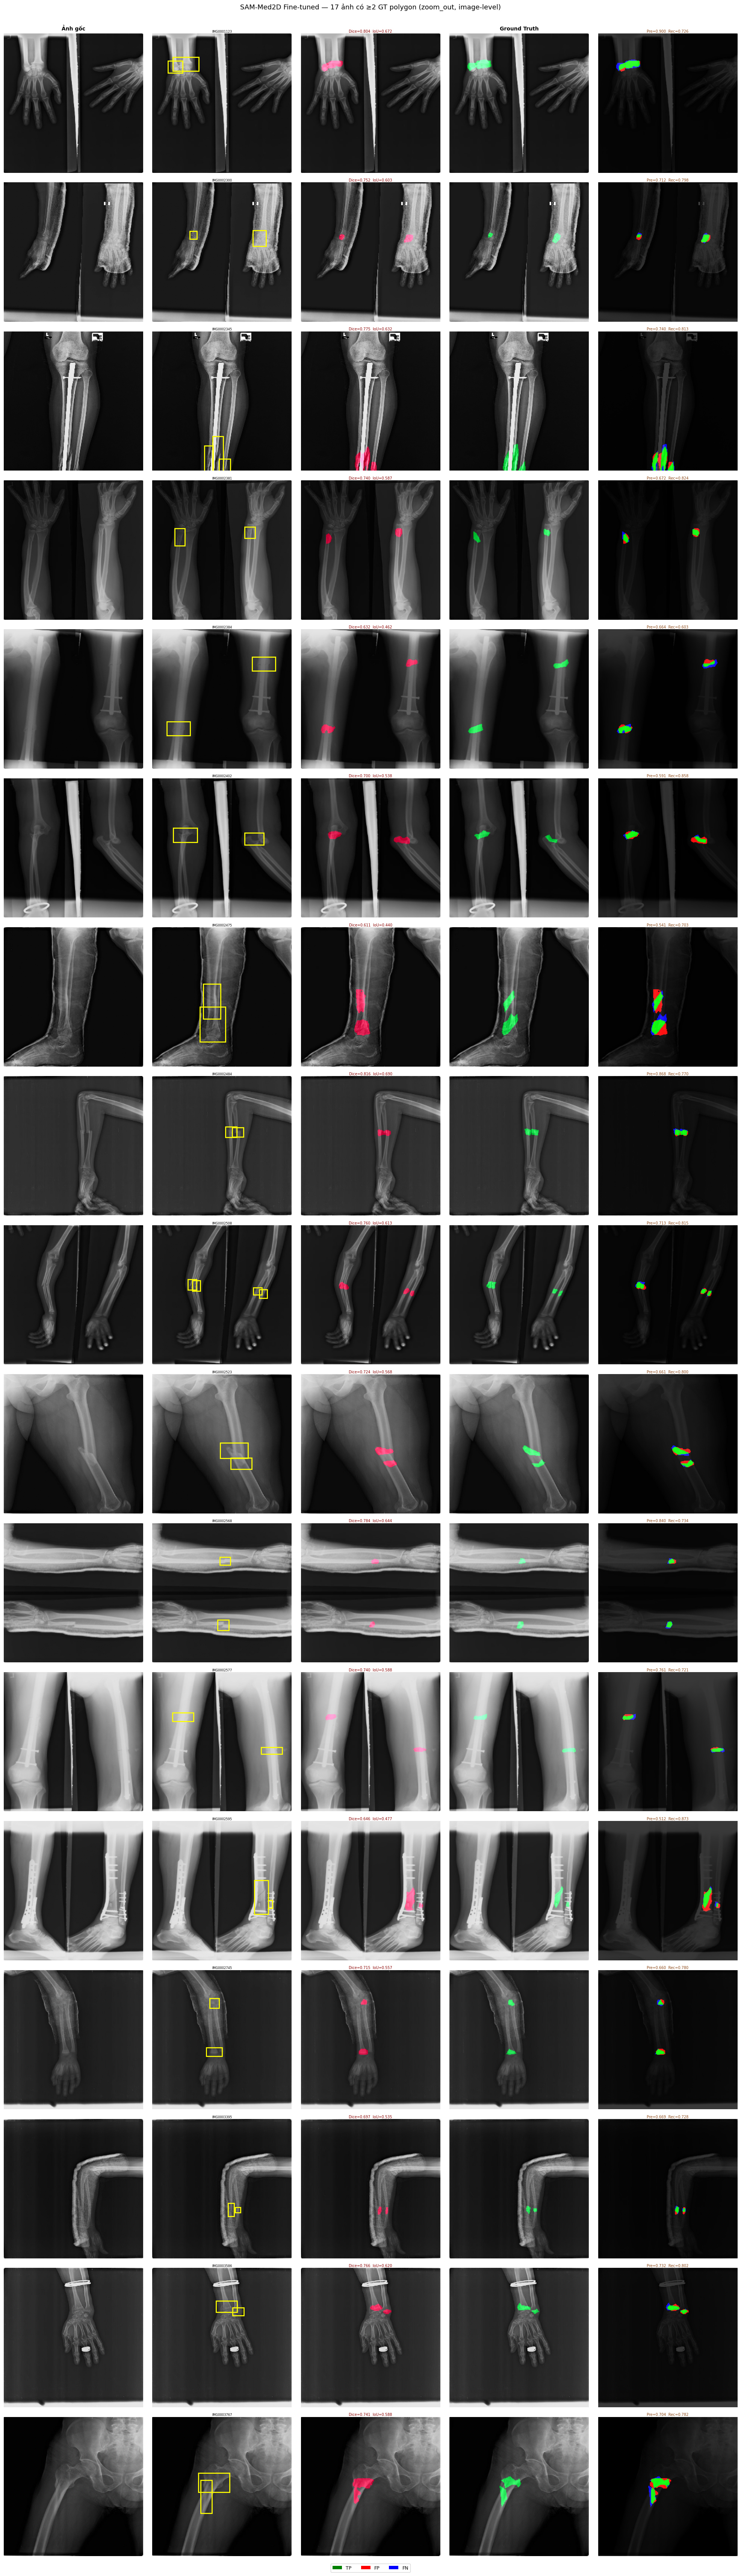

In [10]:
import cv2, numpy as np, os, csv, json as _json, glob as _glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from IPython.display import display as _ipy_display
from scipy.ndimage import binary_erosion, distance_transform_edt

%cd /kaggle/working/SAM-Med2D

MODES     = ['zoom_out', 'shift', 'mixed_7_3']
PRED_DIRS = {m: f"workdir/test_results/sammed/boxes_{m}" for m in MODES}
MASK_DIR  = "dataset_FracAtlas/test/masks"
S = 256

def calc_m(prob, gt, eps=1e-6):
    pm = (prob > 0.5).astype(np.float32)
    gm = (gt   > 0.5).astype(np.float32)
    tp = (pm*gm).sum(); fp = (pm*(1-gm)).sum(); fn = ((1-pm)*gm).sum()
    p, g = pm.astype(bool), gm.astype(bool)
    hd95 = float(S)
    if p.any() and g.any():
        pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
        d1 = distance_transform_edt(~ge)[pe]
        d2 = distance_transform_edt(~pe)[ge]
        if len(d1) and len(d2):
            hd95 = float(max(np.percentile(d1, 95), np.percentile(d2, 95)))
    if gm.sum() == 0 or pm.sum() == 0:
        cbl = 0.
    else:
        ys, xs = np.where(gm > 0.5); yp, xp = np.where(pm > 0.5)
        d = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + eps
        cbl = float(np.clip(1. - np.sqrt((xp.mean()-xs.mean())**2 +
                                          (yp.mean()-ys.mean())**2) / d, 0, 1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)),
                iou =float((tp+eps)/(tp+fp+fn+eps)),
                precision=float((tp+eps)/(tp+fp+eps)),
                recall   =float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)

KEYS = ['dice','iou','precision','recall','hd95','cbl']
HDRS = ['Dice↑','IoU↑','Prec↑','Rec↑','HD95↓','CBL↑']

# ── 1. Metrics image-level ────────────────────────────────────────────────────
print(f'\n{"="*78}')
print('  SAM-Med2D Fine-tuned — IMAGE-LEVEL metrics (GT union + max-merge)')
print(f'{"="*78}')
print(f"  {'Mode':<16}" + ''.join(f'{h:>8}' for h in HDRS) + f"  {'N_img':>6}")
print(f"  {'-'*74}")

os.makedirs('workdir/test_results/csv', exist_ok=True)
all_img_recs = {}

with open('dataset_FracAtlas/label2image_test.json') as _f:
    l2i = _json.load(_f)
img_lookup = {}
for mp, ip in l2i.items():
    st = os.path.basename(mp).rsplit('_', 1)[0]
    if st not in img_lookup: img_lookup[st] = ip

for mode in MODES:
    pred_dir = PRED_DIRS[mode]
    if not os.path.exists(pred_dir):
        print(f'  ⚠ {mode}: chưa có prediction — chạy cell Test trước'); continue

    stem_data = {}
    for fn in sorted(os.listdir(MASK_DIR)):
        if not fn.endswith('.png'): continue
        parts = fn.rsplit('_', 1)
        if len(parts) < 2: continue
        stem = parts[0]
        gt_p = cv2.imread(os.path.join(MASK_DIR,   fn), cv2.IMREAD_GRAYSCALE)
        pr_p = cv2.imread(os.path.join(pred_dir,   fn), cv2.IMREAD_GRAYSCALE)
        if gt_p is None or pr_p is None: continue
        gt256 = cv2.resize(gt_p, (S,S), interpolation=cv2.INTER_NEAREST).astype(np.float32)/255.
        pr256 = cv2.resize(pr_p, (S,S), interpolation=cv2.INTER_NEAREST).astype(np.float32)/255.
        if stem not in stem_data:
            stem_data[stem] = dict(gt=gt256.copy(), prob=pr256.copy(), n=1)
        else:
            np.maximum(stem_data[stem]['gt'],   gt256, out=stem_data[stem]['gt'])
            np.maximum(stem_data[stem]['prob'], pr256, out=stem_data[stem]['prob'])
            stem_data[stem]['n'] += 1

    if not stem_data: continue
    recs = []
    for stem, d in sorted(stem_data.items()):
        m = calc_m(d['prob'], d['gt'])
        recs.append(dict(stem=stem, gt=d['gt'], prob=d['prob'], n=d['n'],
                         img_path=img_lookup.get(stem,''), **m))
    all_img_recs[mode] = recs

    avg = {k: np.mean([r[k] for r in recs]) for k in KEYS}
    print(f"  {mode:<16}" + ''.join(f"{avg[k]:>8.4f}" for k in KEYS) + f"  {len(recs):>6}")

    csv_path = f'workdir/test_results/csv/sammed2d_finetune_{mode}_img.csv'
    with open(csv_path, 'w', newline='') as fc:
        w = csv.writer(fc)
        w.writerow(['model','mode'] + KEYS + ['N_img'])
        w.writerow(['SAM-Med2D-FT', mode] + [f'{avg[k]:.4f}' for k in KEYS] + [len(recs)])
    print(f"    → {csv_path}")

print(f'{"="*78}')

# ── 2. PGA-style 5-col visualization ──────────────────────────────────────────
VIS_MODE = 'zoom_out'
MIN_POLY  = 2
N_MIN     = 10

if VIS_MODE not in all_img_recs:
    print(f"⚠ Chưa có kết quả {VIS_MODE} — chạy Test A trước")
else:
    recs_viz = [r for r in all_img_recs[VIS_MODE] if r['n'] >= MIN_POLY]
    assert len(recs_viz) >= N_MIN, f'Chỉ có {len(recs_viz)} ảnh ≥{MIN_POLY} GT (cần {N_MIN})'
    N_SHOW = len(recs_viz)

    def get_poly_bboxes(stem, r=0.30):
        bboxes = []
        for pm_path in sorted(_glob.glob(os.path.join(MASK_DIR, f"{stem}_*.png"))):
            pm = cv2.imread(pm_path, cv2.IMREAD_GRAYSCALE)
            if pm is None: continue
            pm256 = cv2.resize(pm, (S,S), interpolation=cv2.INTER_NEAREST).astype(np.float32)
            if pm256.max() > 1: pm256 /= 255.
            ys, xs = np.where(pm256 > 0.5)
            if not len(xs): continue
            x0,x1 = int(xs.min()),int(xs.max())
            y0,y1 = int(ys.min()),int(ys.max())
            gw,gh = x1-x0, y1-y0
            bboxes.append((max(0,x0-gw*r), max(0,y0-gh*r),
                           min(S,x1+gw*r)-max(0,x0-gw*r),
                           min(S,y1+gh*r)-max(0,y0-gh*r)))
        return bboxes

    fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4*N_SHOW))
    if N_SHOW == 1: axes = axes[np.newaxis, :]
    fig.suptitle(
        f'SAM-Med2D Fine-tuned — {N_SHOW} ảnh có ≥{MIN_POLY} GT polygon (zoom_out, image-level)',
        fontsize=13, y=1.001)

    for ax, ct in zip(axes[0], ['Ảnh gốc','Ảnh + Bbox Prompts',
                                  'Dự đoán (merged)','Ground Truth','TP/FP/FN']):
        ax.set_title(ct, fontsize=10, fontweight='bold')

    for count, rec in enumerate(recs_viz):
        img_gray = cv2.imread(rec['img_path'], cv2.IMREAD_GRAYSCALE) if rec['img_path'] else None
        if img_gray is not None:
            img_np = cv2.resize(img_gray, (S,S)).astype(np.float32) / 255.
        else:
            img_np = np.zeros((S,S), dtype=np.float32)

        gt_np   = (rec['gt']   > 0.5).astype(float)
        pred_np = (rec['prob'] > 0.5).astype(float)
        e   = 1e-6
        tp  = (pred_np*gt_np).sum()
        fp  = (pred_np*(1-gt_np)).sum()
        fn  = ((1-pred_np)*gt_np).sum()
        dice = float((2*tp+e)/(2*tp+fp+fn+e))
        iou  = float((tp+e)/(tp+fp+fn+e))
        pre  = float((tp+e)/(tp+fp+e))
        rec_ = float((tp+e)/(tp+fn+e))

        row = axes[count]
        bg  = np.stack([img_np]*3, axis=-1)

        # Col 0 – Ảnh gốc
        row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        row[0].set_ylabel(f'#{count+1} [{rec["n"]} poly]\nDice={dice:.3f}', fontsize=8)

        # Col 1 – Ảnh + per-polygon bbox prompts
        row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        for bx in get_poly_bboxes(rec['stem']):
            row[1].add_patch(Rectangle((bx[0],bx[1]), bx[2], bx[3],
                             linewidth=2, edgecolor='yellow', facecolor='none'))
        row[1].set_title(rec['stem'], fontsize=6, pad=2)

        # Col 2 – Dự đoán (red overlay)
        pr_ov = bg.copy()
        pr_ov[...,0] = np.clip(pr_ov[...,0] + pred_np*0.55, 0, 1)
        pr_ov[...,1] = np.clip(pr_ov[...,1] - pred_np*0.20, 0, 1)
        row[2].imshow(pr_ov)
        row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

        # Col 3 – Ground Truth (green overlay)
        gt_ov = bg.copy()
        gt_ov[...,1] = np.clip(gt_ov[...,1] + gt_np*0.55, 0, 1)
        gt_ov[...,0] = np.clip(gt_ov[...,0] - gt_np*0.20, 0, 1)
        row[3].imshow(gt_ov)

        # Col 4 – TP(green) / FP(red) / FN(blue)
        inter = bg.copy() * 0.25
        inter[...,1] = np.clip(inter[...,1] + pred_np*gt_np      *0.9, 0, 1)
        inter[...,0] = np.clip(inter[...,0] + pred_np*(1-gt_np)  *1.0, 0, 1)
        inter[...,2] = np.clip(inter[...,2] + (1-pred_np)*gt_np  *1.0, 0, 1)
        row[4].imshow(inter)
        row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7,
                         color='saddlebrown', pad=2)

        for ax in row: ax.axis('off')

    fig.legend(
        handles=[Patch(facecolor='green', label='TP'),
                 Patch(facecolor='red',   label='FP'),
                 Patch(facecolor='blue',  label='FN')],
        loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.005)
    )
    plt.tight_layout()
    _ipy_display(fig)
    plt.close(fig)